# Full vs Nominal Resolution Comparison

This notebook demonstrates the difference between:
- **Full resolution** (λ²₀ = 0): Narrower restoring beam, better for multiple components
- **Nominal resolution** (λ²₀ = weighted mean): Standard resolution, phase-stable

Based on Rudnick & Cotton (2023), full resolution provides better discrimination of multiple Faraday components.

In [1]:
import copy
import numpy as np
import matplotlib.pyplot as plt
from csromer.simulation import FaradayThinSource
from csromer.pipelines.simulation import run_simulation, SimulateStep, ApplyNoiseStep
from csromer.pipelines.reconstruction import build_parameter, build_measurement_operator
from csromer.utils.array_utils import asnumpy

plt.rcParams['figure.figsize'] = (14, 10)
%matplotlib inline

## 1. Create Source and Check Resolution Properties

In [2]:
# Create source and run simulation pipeline
nu = np.linspace(1.0e9, 1.5e9, 128)
source = FaradayThinSource(nu=nu, s_nu=0.1, phi_gal=50.0, spectral_idx=-0.7)
run_simulation(source, [
    SimulateStep(),
    ApplyNoiseStep(0.01, random_state=np.random.RandomState(42)),
])

# Check resolution properties
print("Resolution Properties:")
print(f"  λ² range: [{np.min(source.lambda2):.6e}, {np.max(source.lambda2):.6e}] m²")
print(f"  λ²₀ (default): {source.l2_ref:.6e} m²")
print(f"\n  Full resolution (λ²₀ = 0):")
print(f"    δφ_full = {source.delta_phi_full:.3f} rad/m²")
print(f"    Formula: 2 / (λ²_max + λ²_min) [Rudnick & Cotton 2023, Eq. 9]")
print(f"\n  Nominal resolution (λ²₀ = weighted mean):")
print(f"    δφ_nom = {source.delta_phi_nom:.3f} rad/m²")
print(f"    Formula: 2√3 / (λ²_max - λ²_min)")
print(f"\n  Ratio (nominal/full): {source.delta_phi_nom / source.delta_phi_full:.2f}x")

Resolution Properties:
  λ² range: [3.994467e-02, 8.987552e-02] m²
  λ²₀ (default): 0.000000e+00 m²

  Full resolution (λ²₀ = 0):
    δφ_full = 15.406 rad/m²
    Formula: 2 / (λ²_max + λ²_min) [Rudnick & Cotton 2023, Eq. 9]

  Nominal resolution (λ²₀ = weighted mean):
    δφ_nom = 69.378 rad/m²
    Formula: 2√3 / (λ²_max - λ²_min)

  Ratio (nominal/full): 4.50x


## 2. Compare Dirty Spectra with Different λ²₀

In [3]:
# Set up parameter grid and two dataset copies (full vs nominal λ²₀)
param = build_parameter(source, oversampling=4.0)
source_nom = copy.deepcopy(source)
source.l2_ref = 0.0
source_nom.l2_ref = source_nom.calculate_l2ref()

# Full resolution (λ²₀ = 0) and nominal resolution via pipeline helpers
op_full, _ = build_measurement_operator(source, param, kind="direct")
fd_dirty_full = op_full.dirty_spectrum(source.data)
fd_dirty_full_np = np.asarray(asnumpy(fd_dirty_full))

op_nom, _ = build_measurement_operator(source_nom, param, kind="direct")
fd_dirty_nom = op_nom.dirty_spectrum(source_nom.data)
fd_dirty_nom_np = np.asarray(asnumpy(fd_dirty_nom))

phi = np.asarray(asnumpy(param.phi))

print(f"\nResolution comparison:")
print(f"  Full resolution (λ²₀ = 0):")
print(f"    λ²₀ = {op_full.dataset.l2_ref:.6e} m²")
print(f"    δφ = {op_full.dataset.delta_phi:.3f} rad/m²")
print(f"\n  Nominal resolution (λ²₀ = weighted mean):")
print(f"    λ²₀ = {op_nom.dataset.l2_ref:.6e} m²")
print(f"    δφ = {op_nom.dataset.delta_phi:.3f} rad/m²")

FWHM of the main peak of the RMTF: 15.406 rad/m^2
Maximum recovered width structure: 78.649 rad/m^2
Maximum Faraday Depth to which one has more than 50% sensitivity: 4405.502

Resolution comparison:
  Full resolution (λ²₀ = 0):
    λ²₀ = 0.000000e+00 m²
    δφ = 15.406 rad/m²

  Nominal resolution (λ²₀ = weighted mean):
    λ²₀ = 5.995634e-02 m²
    δφ = 69.378 rad/m²


### Why do the amplitude spectra look the same?

The reference λ²₀ only introduces a **phase factor**: F_nom(φ) = exp(2j φ λ²₀) F_full(φ), so the **amplitude** |F(φ)| is identical for both. The **resolution** (δφ_full vs δφ_nom) is the formal FWHM of the restoring beam (Rudnick & Cotton 2023) and matters for CLEAN/restoration and for reporting the beam width; it does not change the dirty map amplitude. Below we verify that λ²₀ and δφ differ between the two setups, and plot the **phase** of F(φ) to show they differ.


Dataset comparison (should differ):
  Full:    l2_ref = 0.000000e+00 m²,  δφ = 15.406 rad/m²
  Nominal: l2_ref = 5.995634e-02 m²,  δφ = 69.378 rad/m²
  Same param (cellsize): 3.878083 rad/m²


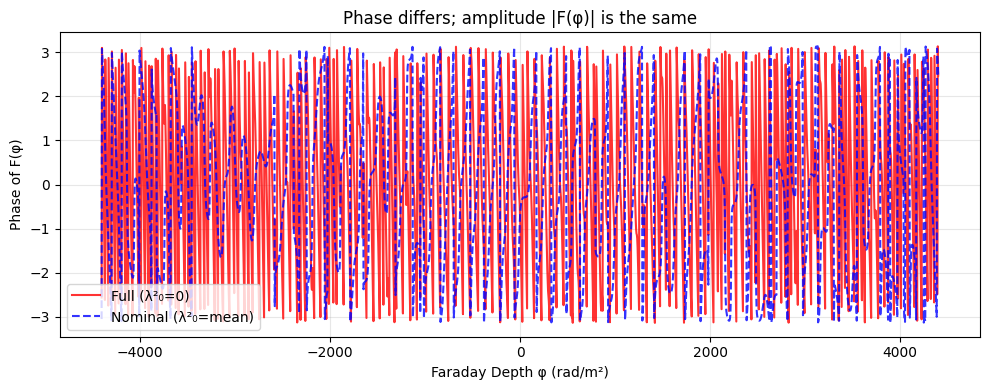

In [4]:
# Sanity check: confirm the two setups have different λ²₀ and δφ
print("Dataset comparison (should differ):")
print(f"  Full:    l2_ref = {op_full.dataset.l2_ref:.6e} m²,  δφ = {op_full.dataset.delta_phi:.3f} rad/m²")
print(f"  Nominal: l2_ref = {op_nom.dataset.l2_ref:.6e} m²,  δφ = {op_nom.dataset.delta_phi:.3f} rad/m²")
print(f"  Same param (cellsize): {param.cellsize:.6f} rad/m²")

# Phase of F(φ) differs; amplitude is the same
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(phi, np.angle(fd_dirty_full_np), 'r-', label='Full (λ²₀=0)', alpha=0.8)
ax.plot(phi, np.angle(fd_dirty_nom_np), 'b--', label='Nominal (λ²₀=mean)', alpha=0.8)
ax.set_xlabel('Faraday Depth φ (rad/m²)')
ax.set_ylabel('Phase of F(φ)')
ax.set_title('Phase differs; amplitude |F(φ)| is the same')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Visualize the Difference

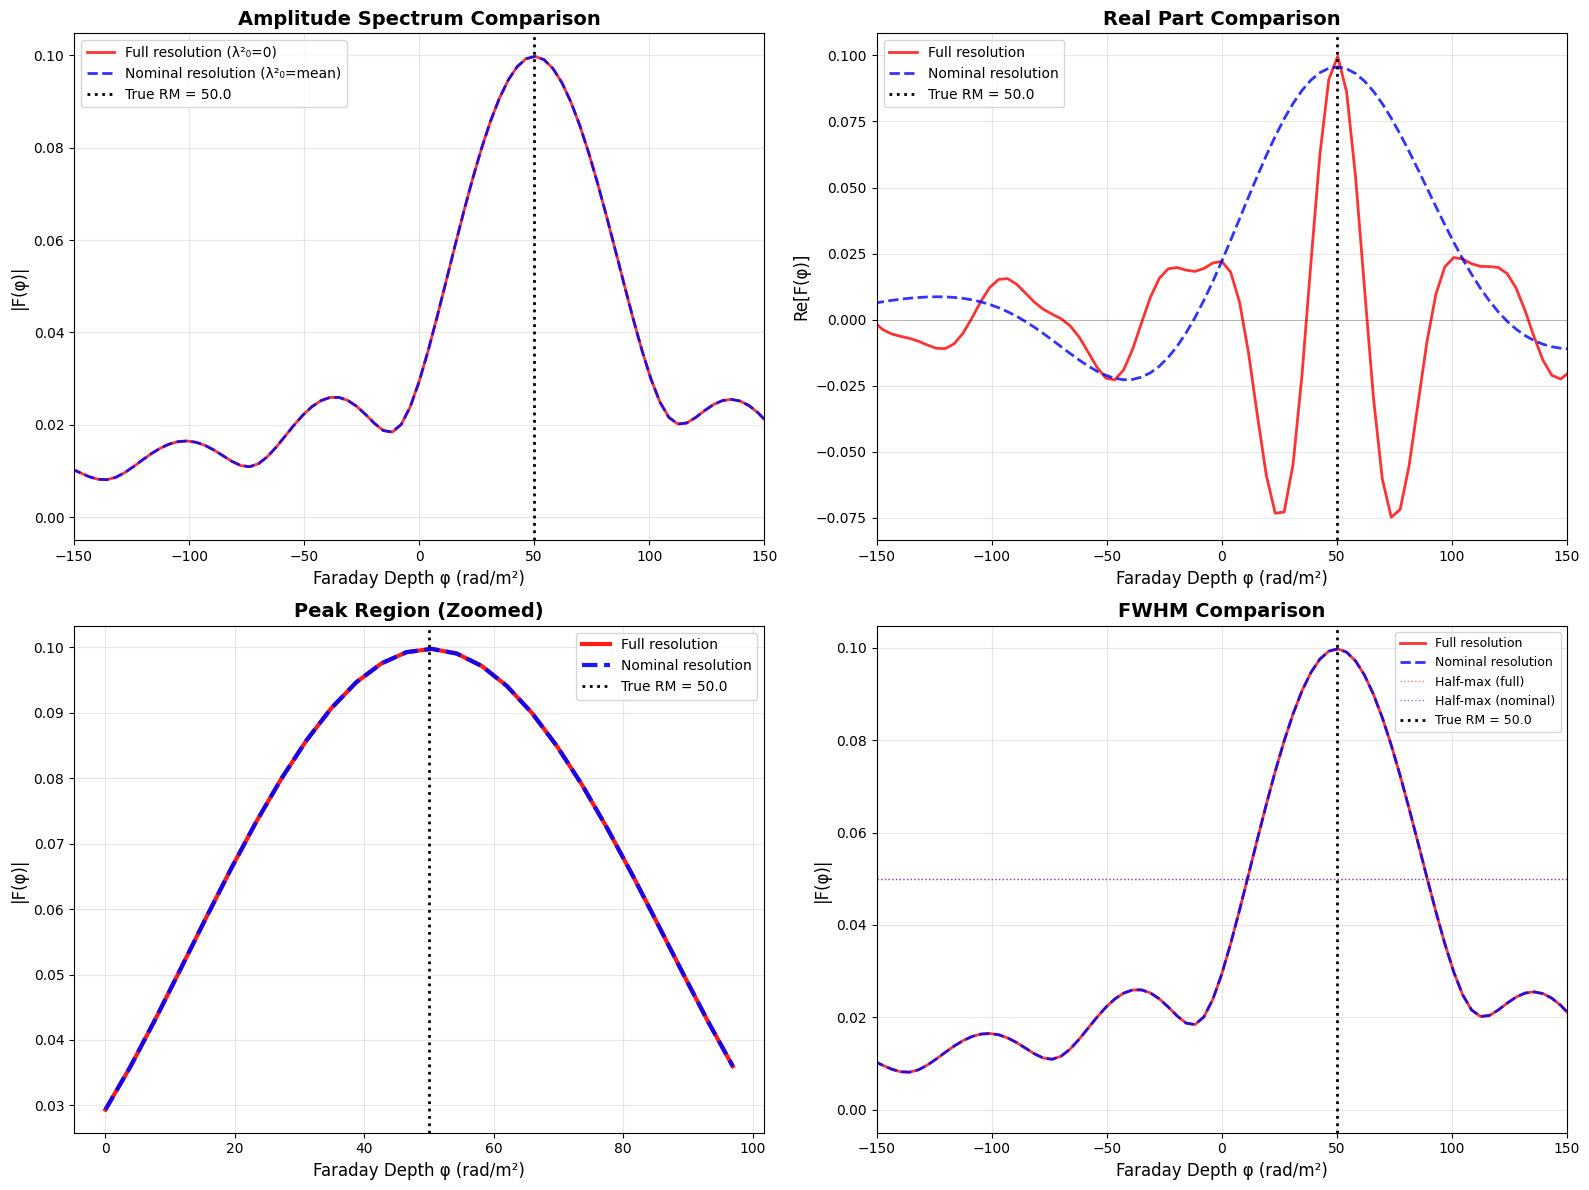


Key Observations:
1. Amplitude spectra are identical (independent of λ²₀)
2. Real and imaginary parts differ (phase shift)
3. Full resolution has narrower real beam peak
4. For multiple components, full resolution provides better discrimination


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Amplitude comparison
ax = axes[0, 0]
ax.plot(phi, np.abs(fd_dirty_full_np), 'r-', linewidth=2, label='Full resolution (λ²₀=0)', alpha=0.8)
ax.plot(phi, np.abs(fd_dirty_nom_np), 'b--', linewidth=2, label='Nominal resolution (λ²₀=mean)', alpha=0.8)
ax.axvline(source.phi_gal, color='k', linestyle=':', linewidth=2, label=f'True RM = {source.phi_gal:.1f}')
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)|', fontsize=12)
ax.set_title('Amplitude Spectrum Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-150, 150)

# Plot 2: Real part comparison
ax = axes[0, 1]
ax.plot(phi, fd_dirty_full_np.real, 'r-', linewidth=2, label='Full resolution', alpha=0.8)
ax.plot(phi, fd_dirty_nom_np.real, 'b--', linewidth=2, label='Nominal resolution', alpha=0.8)
ax.axvline(source.phi_gal, color='k', linestyle=':', linewidth=2, label=f'True RM = {source.phi_gal:.1f}')
ax.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('Re[F(φ)]', fontsize=12)
ax.set_title('Real Part Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-150, 150)

# Plot 3: Zoomed amplitude (peak region)
ax = axes[1, 0]
peak_range = 50
mask = (phi >= source.phi_gal - peak_range) & (phi <= source.phi_gal + peak_range)
ax.plot(phi[mask], np.abs(fd_dirty_full_np[mask]), 'r-', linewidth=3, label='Full resolution', alpha=0.9)
ax.plot(phi[mask], np.abs(fd_dirty_nom_np[mask]), 'b--', linewidth=3, label='Nominal resolution', alpha=0.9)
ax.axvline(source.phi_gal, color='k', linestyle=':', linewidth=2, label=f'True RM = {source.phi_gal:.1f}')
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)|', fontsize=12)
ax.set_title('Peak Region (Zoomed)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 4: FWHM comparison
ax = axes[1, 1]
# Find FWHM for both
peak_full = np.max(np.abs(fd_dirty_full_np))
peak_nom = np.max(np.abs(fd_dirty_nom_np))
half_max_full = peak_full / 2.0
half_max_nom = peak_nom / 2.0

# Find indices where amplitude crosses half-max
mask_full = np.abs(fd_dirty_full_np) >= half_max_full
mask_nom = np.abs(fd_dirty_nom_np) >= half_max_nom

ax.plot(phi, np.abs(fd_dirty_full_np), 'r-', linewidth=2, label='Full resolution', alpha=0.8)
ax.plot(phi, np.abs(fd_dirty_nom_np), 'b--', linewidth=2, label='Nominal resolution', alpha=0.8)
ax.axhline(half_max_full, color='r', linestyle=':', linewidth=1, alpha=0.5, label='Half-max (full)')
ax.axhline(half_max_nom, color='b', linestyle=':', linewidth=1, alpha=0.5, label='Half-max (nominal)')
ax.axvline(source.phi_gal, color='k', linestyle=':', linewidth=2, label=f'True RM = {source.phi_gal:.1f}')
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)|', fontsize=12)
ax.set_title('FWHM Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(-150, 150)

plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("1. Amplitude spectra are identical (independent of λ²₀)")
print("2. Real and imaginary parts differ (phase shift)")
print("3. Full resolution has narrower real beam peak")
print("4. For multiple components, full resolution provides better discrimination")

## 4. Test with Multiple Components

Demonstrate the advantage of full resolution for multiple Faraday components.

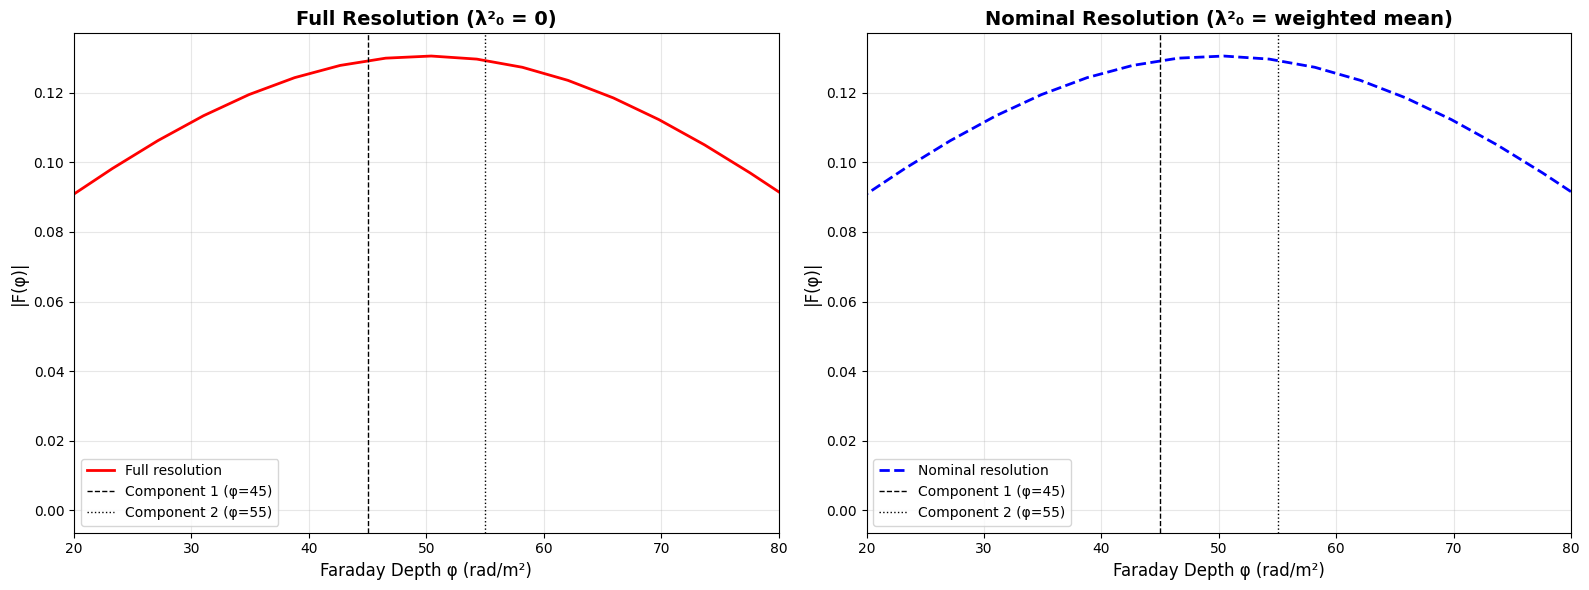


Multiple Component Analysis:
Full resolution provides better separation of closely spaced components.
This is the key advantage identified by Rudnick & Cotton (2023).


In [6]:
# Last cell can be run standalone: ensure imports and nu exist
import copy
import numpy as np
import matplotlib.pyplot as plt
from csromer.simulation import FaradayThinSource
from csromer.reconstruction import Parameter
from csromer.transformers.measurement_operator import DirectFourier1D
from csromer.utils.array_utils import asnumpy

if 'nu' not in dir():
    nu = np.linspace(1.0e9, 1.5e9, 128)

# Create two closely spaced sources (simulate each before adding)
source1 = FaradayThinSource(nu=nu, s_nu=0.08, phi_gal=45.0, spectral_idx=-0.7)
source2 = FaradayThinSource(nu=nu, s_nu=0.08, phi_gal=55.0, spectral_idx=-0.7)
source1.simulate()
source2.simulate()
source_multi = source1 + source2
source_multi.apply_noise(0.01, random_state=np.random.RandomState(42))

# Set up parameter grid
param_multi = Parameter()
param_multi.calculate_cellsize(dataset=source_multi, oversampling=4.0, verbose=False)

# Use two dataset copies so each operator keeps its own λ²₀
source_multi_nom = copy.deepcopy(source_multi)
source_multi.l2_ref = 0.0
source_multi_nom.l2_ref = source_multi_nom.calculate_l2ref()

# Full resolution
op_multi_full = DirectFourier1D(dataset=source_multi, parameter=param_multi)
fd_multi_full = op_multi_full.dirty_spectrum(source_multi.data)
fd_multi_full_np = np.asarray(asnumpy(fd_multi_full))

# Nominal resolution
op_multi_nom = DirectFourier1D(dataset=source_multi_nom, parameter=param_multi)
fd_multi_nom = op_multi_nom.dirty_spectrum(source_multi_nom.data)
fd_multi_nom_np = np.asarray(asnumpy(fd_multi_nom))

phi_multi = np.asarray(asnumpy(param_multi.phi))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full resolution
ax = axes[0]
ax.plot(phi_multi, np.abs(fd_multi_full_np), 'r-', linewidth=2, label='Full resolution')
ax.axvline(45.0, color='k', linestyle='--', linewidth=1, label='Component 1 (φ=45)')
ax.axvline(55.0, color='k', linestyle=':', linewidth=1, label='Component 2 (φ=55)')
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)|', fontsize=12)
ax.set_title('Full Resolution (λ²₀ = 0)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(20, 80)

# Nominal resolution
ax = axes[1]
ax.plot(phi_multi, np.abs(fd_multi_nom_np), 'b--', linewidth=2, label='Nominal resolution')
ax.axvline(45.0, color='k', linestyle='--', linewidth=1, label='Component 1 (φ=45)')
ax.axvline(55.0, color='k', linestyle=':', linewidth=1, label='Component 2 (φ=55)')
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)|', fontsize=12)
ax.set_title('Nominal Resolution (λ²₀ = weighted mean)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(20, 80)

plt.tight_layout()
plt.show()

print("\nMultiple Component Analysis:")
print("Full resolution provides better separation of closely spaced components.")
print("This is the key advantage identified by Rudnick & Cotton (2023).")